# HW02: Optimization Techniques for "Bad" Objective Functions

**CS 182 · Fall 2026**


In this homework, we will be learning a 2-parameter model $f(x, y)$ ($x$ and $y$ are the two parameters) using different optimization techniques. Formally, the problem we are trying to solve is

$$\arg\max_{x, y} f(x, y)$$

Our function has the following closed form:

$$f(x, y) = \sin(2.5x-5y) + \cos(4x + 8y) - (x-2)^2 - (y-2)^2.$$


As you might have already guessed, this objective function has a lot of local maxima (points higher than their immediate neighbors).

In this notebook, you will see how ordinary gradient ascent might run into issues optimizing such a function and learn about a couple of other optimization techniques that can help with local maxima.

To get started, let's first write the function in code and visualize it (brighter color = higher value).

For the written comparisons, change one setting at a time and keep the initial point and number of update steps fixed unless instructed otherwise. Qualitative observations with explanations are sufficient.


**Setup and workflow.** Use Python 3 with NumPy, Matplotlib, and ipywidgets in Jupyter or Google Colab. Complete each TODO, then run that cell and the following cells in order. The first smoothing plot evaluates a Monte Carlo estimate over a grid and may take a little time. The sliders recompute trajectories; keep the random seed fixed to compare settings, and change it to repeat the experiment. The stars mark approximate maximizers on the plotted grid, not exact analytical solutions.


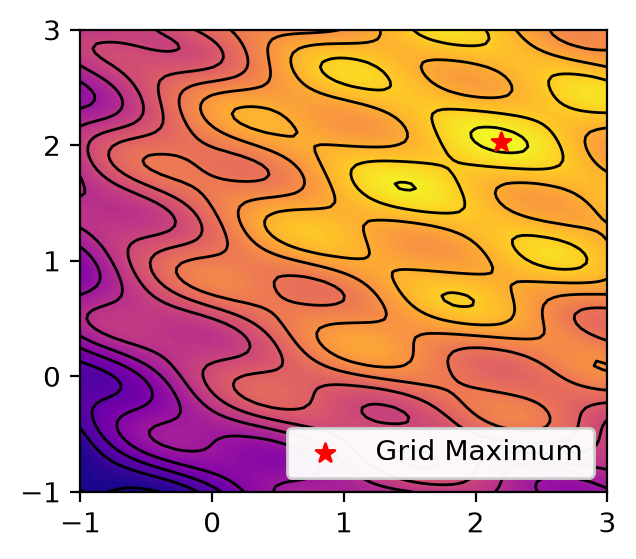

In [1]:
import numpy as np

def f(x, y):
  return np.sin(2.5 * (x - 2 * y)) + np.cos(4.0 * (x + 2 * y)) - ((x - 2.0) ** 2 + (y - 2.0) ** 2)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interactive, widgets

np.random.seed(2026)

# add contour line
plt.rcParams['contour.negative_linestyle'] = 'solid'

class Visualizer:
  def __init__(self, func, x_lim=(-1, 3), y_lim=(-1, 3), res=100, n_contour_lines=15, quantized_values=None):
    xs = np.linspace(*x_lim, res)
    ys = np.linspace(*y_lim, res)
    self.xs, self.ys = np.meshgrid(xs, ys)
    self.zs = func(self.xs, self.ys)

    index = np.argmax(self.zs.reshape(-1))
    self.opt_x, self.opt_y = self.xs.reshape(-1)[index], self.ys.reshape(-1)[index]
    self.x_lim, self.y_lim = x_lim, y_lim

    self.n_contour_lines = n_contour_lines
    self.quantized_values = quantized_values

  def _plot_base_function(self, ax, no_bg=False, alpha=1.0, new_zs=None, new_opt=None):
    if new_zs is not None:
      zs = new_zs
    else:
      zs = self.zs
    if not no_bg:
      ctf = ax.contourf(self.xs, self.ys, zs, 100, cmap='plasma')
    ax.contour(self.xs, self.ys, zs, self.n_contour_lines, linewidths=1, colors="black", alpha=alpha)

    if self.quantized_values is not None:
      assert not no_bg
      patches = []
      for q in self.quantized_values:
        color = ctf.to_rgba(q)
        patches.append(mpatches.Patch(color=color, label=f'$f_q(x, y)={q}$'))
      legend = ax.legend(handles=patches, loc='best', ncol=3, fontsize="small")
      ax.add_artist(legend)
    else:
      if new_opt is None:
        ax.scatter(self.opt_x, self.opt_y, marker="*", s=50, color="red", label="Grid Maximum", zorder=4)
      else:
        ax.scatter(self.opt_x, self.opt_y, marker="*", s=50, color="red", label="Grid Maximum (Original)", zorder=4, alpha=0.75)
        ax.scatter(*new_opt, marker="*", s=50, color="darkgreen", label="Estimated Grid Maximum (Smoothed)", zorder=4, alpha=0.75)

  def draw(self, ax, curves=None, no_bg=False, plot_base=True, base_alpha=1.0,
           new_zs=None, new_opt=None, legend=True):
    ax.clear()
    if plot_base:
      self._plot_base_function(ax, no_bg=no_bg, alpha=base_alpha, new_zs=new_zs, new_opt=new_opt)
    if curves is not None:
      for label, curve in curves.items():
        xs = curve["x"]
        ys = curve["y"]

        lines = []
        for x1, x2, y1, y2 in zip(xs[:-1], xs[1:], ys[:-1], ys[1:]):
            lines.extend([(x1, x2), (y1, y2)])

        ax.plot(*lines, color=curve["color"], linestyle="-", linewidth=2.0, alpha=0.25, zorder=4)
        ax.scatter(xs, ys, marker="o", facecolors='none', edgecolors=curve['color'], s=25, label=label, alpha=0.8, zorder=5)

    ax.set_xticks(np.linspace(-1., 3., 5))
    ax.set_yticks(np.linspace(-1., 3., 5))
    ax.set_xlim(*self.x_lim)
    ax.set_ylim(*self.y_lim)
    if legend:
      handles, labels = ax.get_legend_handles_labels()
      legend = ax.legend(handles=handles, labels=labels, loc='lower right')
      ax.add_artist(legend)


visualizer = Visualizer(f)

fig, ax = plt.subplots(1, 1, figsize=(3.4, 3.0), dpi=200)
visualizer.draw(ax)

As you may have already noticed, there are a lot of local optima in this function. Would this be an issue for gradient ascent? Let's take a look!


## Part 1. Gradient Ascent

In this part, we are going to implement gradient ascent and see how it does on this objective function. Your task is to fill in the `gd_step` function below. The function takes in the parameters $x_t$, $y_t$, and the learning rate $\eta$ and outputs a tuple $(x_{t+1}, y_{t+1})$ after one gradient step:

$$x_{t+1} \leftarrow x_t + \eta \frac{\partial f}{\partial x}(x_t, y_t),$$
$$y_{t+1} \leftarrow y_t + \eta \frac{\partial f}{\partial y}(x_t, y_t).$$

Your code should be able to take either scalar $x$ and $y$ or numpy arrays of $x$ and $y$ as input (in that case your output would be a tuple of array rather than a tuple of scalars).

Once you are done implementing the function, run the cell below and see how gradient ascent optimizes this objective function (you will see the trajectory of $\{(x_1, y_1), \cdots, (x_T, y_T)\}$). You should feel free to change the initialization of $x, y$ parameters and see how different initializations change the optimization trajectory (the line where it says `CHANGE ME!` below).

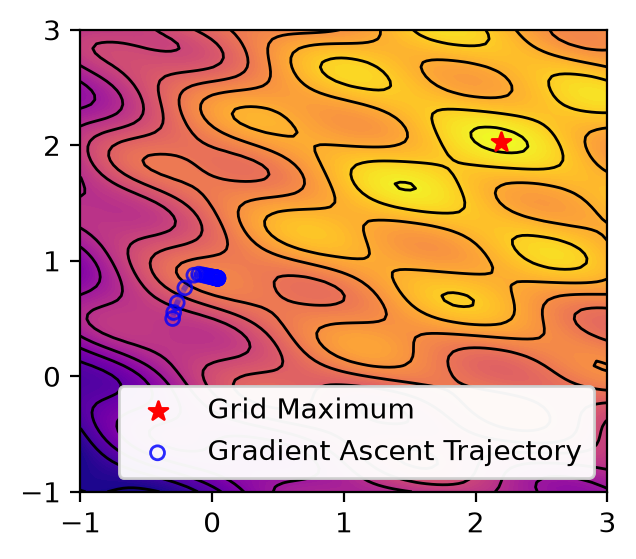

In [2]:
def grad_f(x, y):
  dx = 2.5 * np.cos(2.5 * (x - 2 * y)) - 4.0 * np.sin(4.0 * (x + 2 * y)) - 2.0 * (x - 2.0)
  dy = -5.0 * np.cos(2.5 * (x - 2 * y)) - 8.0 * np.sin(4.0 * (x + 2 * y)) - 2.0 * (y - 2.0)
  return dx, dy

num_its = 100

def gd_step(x, y, eta):
  #############################################################################
  # TODO: Implement gradient ascent step to change your parameters (x, y)     #
  #   in the gradient direction (step size = eta).                            #
  # Hint: You may use the grad_f(x, y) that computes the gradient of f.       #
  #############################################################################
  dx, dy = grad_f(x, y)
  new_x = x + eta * dx
  new_y = y + eta * dy
  #############################################################################
  #                             END OF YOUR CODE                              #
  #############################################################################
  return new_x, new_y

num_its = 30      # number of gradient steps
eta = 0.01        # learning rate
x, y = -0.3, 0.5  # initial parameter values (CHANGE ME!)

# history of parameter values
xs = [x]
ys = [y]

for i in range(num_its):
    x, y = gd_step(x, y, eta)
    xs.append(x)
    ys.append(y)

fig, ax = plt.subplots(1, 1, figsize=(3.4, 3.0), dpi=200)
visualizer.draw(ax, {f"Gradient Ascent Trajectory": {"color": "blue", "x": xs, "y": ys}})

--------------
**(a) What do you observe from the optimization trajectory of $(x,y)$? Where do the parameters appear to converge? Try a few initial points at the same learning rate, and compare whether the endpoints reach a local or the global maximum.**

**Solution.** From the default start $(-0.3, 0.5)$ with $\eta = 0.01$, gradient ascent climbs the nearest hill and settles within about 30 steps near $(0.04, 0.85)$, where $f \approx -3.5$. That is a local maximum, far from the grid maximum near $(2.19, 2.03)$ with $f \approx 1.95$. Other starts behave the same way: $(1, 1)$ ends near $(0.75, 1.25)$ with $f \approx -0.27$, and $(2, 0)$ ends near $(2.25, -0.32)$ with $f \approx -3.65$. Only starts already close to the global maximum, such as $(2.2, 2.0)$ or $(1.5, 2.3)$, reach it ($f \approx 1.96$). Running 1000 steps instead of 30 does not change any of these endpoints.

--------------

In the next part, we are going to cluster these initialization locations by their values at the end of their optimization trajectories.

In [3]:
# Group endpoints that are within eps of a representative endpoint.
def manual_clustering(t_xs, t_ys, eps=1e-2):
  labels = np.full_like(t_xs, -1, dtype=int)
  codebook = []
  while np.any(labels < 0):
    first = tuple(np.argwhere(labels < 0)[0])
    codebook.append(np.array([t_xs[first], t_ys[first]]))
    matched = ((t_xs[first] - t_xs) ** 2 + (t_ys[first] - t_ys) ** 2 <= eps ** 2)
    labels[matched & (labels < 0)] = len(codebook) - 1
  return np.array(codebook), labels

# Generate a grid of initial points and run gradient ascent.
t_xs, t_ys = np.meshgrid(np.linspace(-1, 3, 100), np.linspace(-1, 3, 100))
num_its = 1000
t_xs_history, t_ys_history = [t_xs], [t_ys]
for i in range(num_its):
    t_xs, t_ys = gd_step(t_xs, t_ys, 0.01)
    t_xs_history.append(t_xs)
    t_ys_history.append(t_ys)

codebook, basin_labels = manual_clustering(t_xs, t_ys)


Let's take a look at all the local maxima (the "x" symbols) that we obtained from clustering.

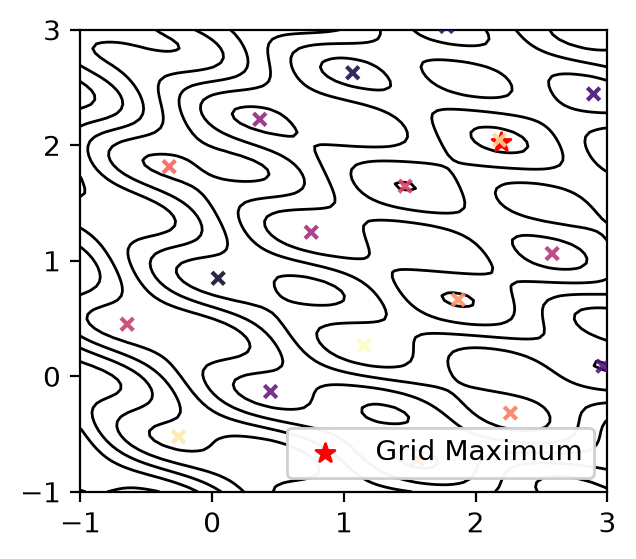

In [4]:
basin_cmap = matplotlib.colormaps['magma']
basin_colors = np.array([basin_cmap(value) for value in np.linspace(0, 1.0, len(codebook))])
np.random.default_rng(2).shuffle(basin_colors)

fig, ax = plt.subplots(1, 1, figsize=(3.4, 3), dpi=200)
visualizer.draw(ax, no_bg=True)
ax.scatter(codebook[:, 0], codebook[:, 1], color=basin_colors, alpha=0.9, s=20, marker="x", zorder=5)


Now, we can visualize the trajectories of these clustered initialization points colored with their corresponding clustering labels via the following interaction widget. The slider corresponds to the gradient step. At step 0, we can see the [basins of attraction](https://en.wikipedia.org/wiki/Attractor) towards these local optima. Try to drag the slider yourself to see how each initialization moves throughout the optimization process!

In [ ]:
def update_basins(i):
  fig, ax = plt.subplots(1, 1, figsize=(3.4, 3), dpi=200)
  ax.set_facecolor('lightgray')
  visualizer.draw(ax, no_bg=True)
  ax.scatter(t_xs_history[i].reshape(-1), t_ys_history[i].reshape(-1), facecolors='none', edgecolors=basin_colors[basin_labels.reshape(-1)], alpha=0.3, s=20, marker="o", zorder=5)
  plt.show()

basin_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(t_xs_history) - 1,
    continuous_update=False,
    description="# of gd steps"
)
basin_widget = interactive(update_basins, i=basin_slider)
basin_widget

--------------
**(b) In the basins-of-attraction plot, points with the same color approach the same local maximum. What patterns do you observe? How do their orientations and repeated structure relate to the sine and cosine terms in $f$?**

**Solution.** The basins form a periodic, tilted pattern of cells, and each cell flows to one local maximum. The term $\sin(2.5(x-2y))$ is constant along lines $x - 2y = \text{const}$ (slope $1/2$) and repeats every $2\pi/2.5$ in $x - 2y$; the term $\cos(4(x+2y))$ is constant along lines $x + 2y = \text{const}$ (slope $-1/2$) and repeats every $2\pi/4$ in $x + 2y$. Together they create a lattice of bumps whose rows run along these two diagonal directions, so the basins are repeated parallelogram-shaped regions with those orientations. The quadratic term $-(x-2)^2-(y-2)^2$ tilts the whole lattice so that bumps near $(2, 2)$ are highest. From the $100 \times 100$ grid of starting points, gradient ascent ends at 23 different local maxima, and only about 7% of the starting points reach the global one.

--------------

Next, we study how the optimization trajectory changes as the learning rate changes. Try to drag the slider to change the learning rate below and see how the trajectories from different initialization points change!

In [ ]:
from functools import partial

cmap = matplotlib.colormaps['ocean']
seed = 1437

rng = np.random.default_rng(seed=seed)
num_its = 15
num_inits = 3
init_xs, init_ys = rng.random(num_inits) * 0.9, rng.random(num_inits) * 1.2
trajectory_colors = [cmap(x) for x in np.linspace(0, 0.6, num_inits)]

def generate_curves(eta, optimizer, num_its, num_inits):
  xs, ys = np.empty((num_its + 1, num_inits)), np.empty((num_its + 1, num_inits))
  xs[0], ys[0] = init_xs, init_ys
  for i in range(1, num_its + 1):
    xs[i], ys[i] = optimizer(xs[i-1], ys[i-1], eta)

  curves = {}
  for i in range(num_inits):
    curves[f"Trajectory (Init #{i+1})"] = {"color": trajectory_colors[i], "x": xs[:, i], "y": ys[:, i]}
  return curves


def get_ascent_interactive(visualizer, gen_fn):

  def update_ascent(eta):
    fig, ax = plt.subplots(1, 1, figsize=(4.0, 4.0), dpi=200)
    curves = gen_fn(eta)
    visualizer.draw(ax, curves)
    plt.show()

  slider = widgets.FloatLogSlider(
      value=0.001,
      base=10,
      min=-3, # min exponent of base
      max=-1, # max exponent of base
      step=0.2, # exponent step
      description='eta',
      continuous_update=False
  )
  return interactive(update_ascent, eta=slider)

ascent_widget = get_ascent_interactive(visualizer, partial(generate_curves, optimizer=gd_step, num_its=num_its, num_inits=num_inits))
ascent_widget

--------------
**(c) How does increasing the learning rate $\eta$ affect the trajectory and final objective value? Does a larger learning rate reliably reach the global maximum? Propose one modification to gradient ascent that might help it escape a local maximum.**

**Solution.** With a small learning rate ($\eta = 0.001$) the iterates barely move in 15 steps. Up to about $\eta = 0.025$ each trajectory converges smoothly to its nearest local maximum. Around $\eta \approx 0.04$ to $0.06$ the steps become large enough to jump over small hills: some starts end much higher (one reaches $f \approx 1.5$), but others land in worse places and the paths become jerky. At $\eta = 0.1$ the iterates bounce around and end at poor values (as low as $f \approx -6.6$). So no single learning rate reliably finds the global maximum: too small gets trapped, too large is unstable. Possible fixes include adding noise to the updates with a decaying learning rate (as in simulated annealing), random restarts, momentum, or optimizing a smoothed objective, as in the next part.

--------------

## Part 2: Smoothing the optimization problem

We have seen that it is very difficult for gradient ascent to reliably find the global maximum, because many initial points lead to other local maxima. This is due to all the small "hills" and "puddles" that trap the optimization trajectories. Can we optimize a different problem that has a similar global optimum but a much nicer objective landscape?

In this part, we explore a smoothing technique that converts the original objective function into a more smoothed one. In particular, we convolve a 2-D Gaussian kernel over the function ([convolution](https://en.wikipedia.org/wiki/Convolution), [Gaussian kernel](https://en.wikipedia.org/wiki/Gaussian_function)):

$$f_{\sigma}(x, y) = \mathbb{E}_{\tilde{x} \sim \mathcal{N}(x, \sigma^2), \tilde{y} \sim \mathcal{N}(y, \sigma^2)}\left[f(\tilde{x}, \tilde{y})\right]$$

At each point, smoothing averages the objective at nearby points, with the Gaussian controlling how far away those points typically lie.

Let's first try to visualize the smoothed objective. To practice estimating expectations, we will approximate it with a Monte Carlo estimate:
$$\hat{f}_\sigma(x, y) = \frac{1}{N} \sum_{i} \left[f(\tilde{x}_i, \tilde{y}_i)\right]$$
with $\tilde{x}_1, \tilde{x}_2, \cdots, \tilde{x}_N$ being independent samples from $\mathcal{N}(x, \sigma^2)$ and $\tilde{y}_1, \tilde{y}_2, \cdots, \tilde{y}_N$ being independent samples from $\mathcal{N}(y, \sigma^2)$.

Your task is to implement the `smoothed_f` function below that returns a Monte-Carlo estimate of $f_\sigma$ using parameters $\sigma$ and $N$. The function should return a float scalar.

In [7]:
def smoothed_f(x, y, sigma, N):
  #############################################################################
  # TODO: Implement the Monte-Carlo estimate of the smoothed function f using #
  #   N samples.                                                              #
  #############################################################################
  tx = np.random.normal(x, sigma, size=(N,))  # tilde x samples
  ty = np.random.normal(y, sigma, size=(N,))  # tilde y samples
  return float(np.mean(f(tx, ty)))
  #############################################################################
  #                             END OF YOUR CODE                              #
  #############################################################################

In [8]:
np.random.seed(2026)
plot_samples = 10000  # Samples per point; increase for a less noisy landscape.
zs_dict = {}
opt_dict = {}
for sigma in [0.01, 0.1, 0.2, 0.3, 0.5]:
  zs = []
  xs, ys = visualizer.xs, visualizer.ys
  for x, y in zip(xs.reshape(-1), ys.reshape(-1)):
    zs.append(smoothed_f(x, y, sigma, N=plot_samples))
  zs_dict[sigma] = np.array(zs).reshape(xs.shape)
  index = np.argmax(zs_dict[sigma].reshape(-1))
  opt_dict[sigma] = (xs.reshape(-1)[index], ys.reshape(-1)[index])

In [ ]:
def update_smoothing(sigma):
  fig, ax = plt.subplots(1, 1, figsize=(4.0, 4.0), dpi=200)
  xs, ys = visualizer.xs, visualizer.ys
  zs = zs_dict[sigma]
  ax.contourf(xs, ys, zs, 50, cmap='plasma')
  ax.contour(xs, ys, zs, 15, linewidths=1, colors="black")

  ax.scatter(visualizer.opt_x, visualizer.opt_y, marker="*", s=50, color="red", label="Grid Maximum (Original)", alpha=0.5, zorder=4)
  ax.scatter(*opt_dict[sigma], marker="*", s=50, color="darkgreen", label="Estimated Grid Maximum (Smoothed)", alpha=0.5, zorder=4)
  ax.legend()
  plt.show()

smoothing_slider = widgets.SelectionSlider(
    options=[0.01, 0.1, 0.2, 0.3, 0.5],
    value=0.01,
    description='sigma',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True
)
smoothing_widget = interactive(update_smoothing, sigma=smoothing_slider)
smoothing_widget

--------------

**(d) Compare the plotted maximizers of the original and smoothed functions, using the legend labels. How does the location of the smoothed maximizer change as $\sigma$ increases? Why? Give an example where smoothing moves the maximizer far from its original location. A one-dimensional sketch and explanation are sufficient.**

**Solution.** For small $\sigma$ ($0.01$ to $0.2$) the smoothed maximizer stays at essentially the original one, near $(2.1, 2.1)$. As $\sigma$ grows it moves toward $(2, 2)$, the center of the quadratic term (about $(2.07, 2.00)$ at $\sigma = 0.3$ and $0.5$, and $(1.93, 2.00)$ at $\sigma = 1$). Smoothing averages $f$ over a Gaussian neighborhood, which damps each oscillating term: the Gaussian average of $\sin(a(x-2y))$ is scaled by $e^{-5a^2\sigma^2/2}$, which at $\sigma = 0.3$ is about $0.24$ for the sine and $0.03$ for the cosine. What remains is dominated by the smooth quadratic, so the smoothed maximizer reflects which *region* is high on average rather than the exact location of the highest narrow peak.

Example: $f(x) = -x^2 + \mathbb{1}\{|x - 1000| < \delta\}\,(x^2 + 1)$ with tiny $\delta > 0$. Its maximum is the narrow spike at $x = 1000$, where $f = 1$, but Gaussian smoothing almost erases the spike, so the smoothed function is nearly $-x^2$ and its maximizer is near $x = 0$, very far from $x = 1000$.

--------------

The displayed smoothed landscape has less pronounced small-scale oscillations. Next we compare three ways to estimate its gradient, using $\sigma=0.3$. Smoothing does not guarantee that every objective has a unique maximum.


## Part 3a: Finite-difference method

The first method that we are going to explore is the finite-difference method where we are going to approximate the gradient by trying to step in each dimension of $\theta$ and evaluate the difference in the objective function:

$$ \frac{\partial f_{\sigma}(x, y)}{\partial x} \approx \frac{\hat{f}_{\sigma}(x + \delta, y) - \hat{f}_{\sigma}(x, y)}{\delta}$$
$$ \frac{\partial f_{\sigma}(x, y)}{\partial y} \approx \frac{\hat{f}_{\sigma}(x, y + \delta) - \hat{f}_{\sigma}(x, y)}{\delta}$$

Here $\hat f_\sigma$ is the Monte Carlo estimate from Part 2. Reuse the same $N$ Gaussian noise samples in the baseline and both perturbed evaluations: for each sampled $(\tilde x_i,\tilde y_i)$, compare $f(\tilde x_i+\delta,\tilde y_i)$ and $f(\tilde x_i,\tilde y_i+\delta)$ with $f(\tilde x_i,\tilde y_i)$. This reduces noise in the differences.

Your task is to implement the `finite_diff_grad_step` function below. In the function, you should first estimate the gradient of the smoothed function $f_\sigma$ using the finite-difference method using $\delta$, $\sigma$, and $N$. Then, you should use the gradient estimate to take a step with a step size of $\eta$ and return the new parameter values.

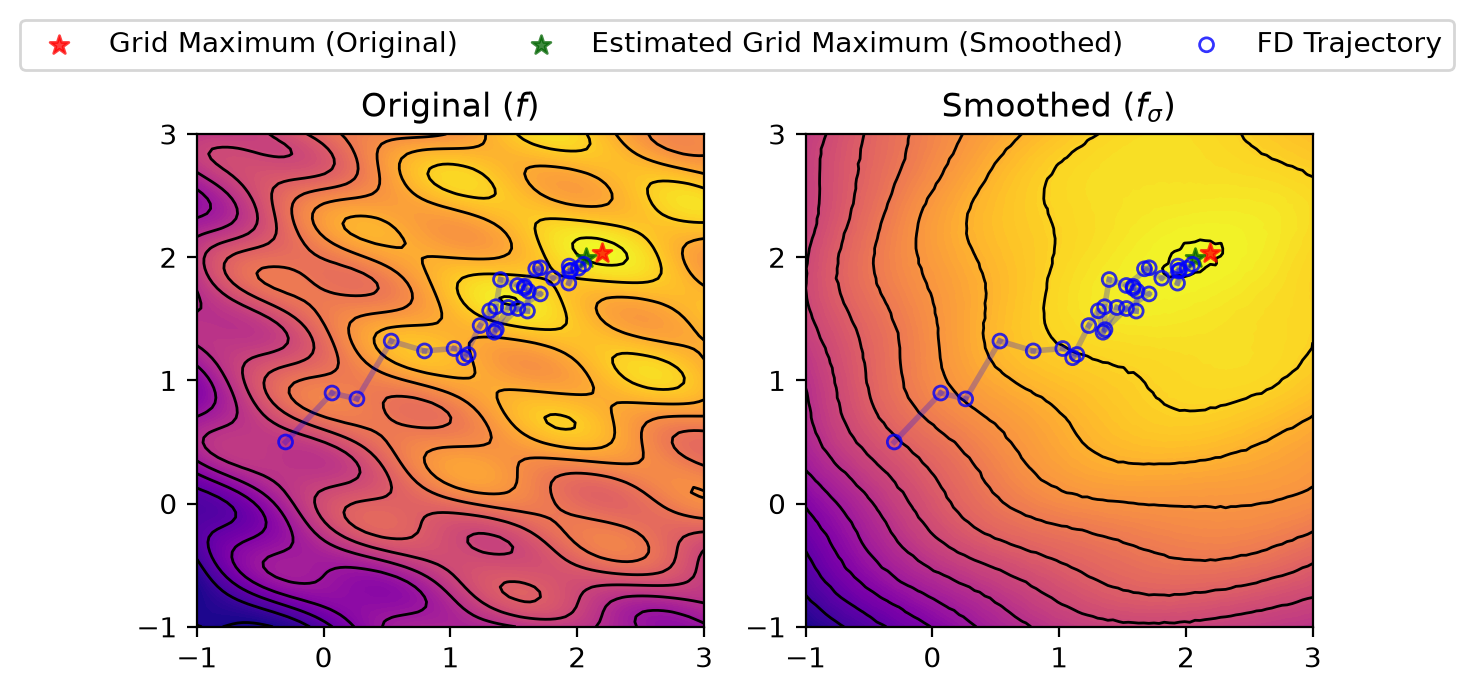

In [10]:
def finite_diff_grad_step(x, y, delta, N, eta, sigma):
  tx = np.random.normal(x, sigma, size=(N,)) # tilde x samples
  ty = np.random.normal(y, sigma, size=(N,)) # tilde y samples
  #############################################################################
  # TODO: Implement the finite-difference gradient estimator of the smoothed  #
  #   function f.                                                             #
  #############################################################################
  # Reuse the same noise samples for the baseline and both perturbed evaluations.
  base = f(tx, ty)
  grad_x = np.mean((f(tx + delta, ty) - base) / delta)
  grad_y = np.mean((f(tx, ty + delta) - base) / delta)
  new_x = x + eta * grad_x
  new_y = y + eta * grad_y
  #############################################################################
  #                             END OF YOUR CODE                              #
  #############################################################################
  return new_x, new_y

num_its = 30      # number of gradient steps
eta = 0.1         # learning rate
delta = 0.25      # finite difference magnitude
N = 20            # number of samples for MC estimation
sigma = 0.3       # the magnitude of the Gaussian noise.
x, y = -0.3, 0.5  # initial parameter values

np.random.seed(2026)  # Reset to make the default trajectory reproducible.

# history of parameter values
xs = [x]
ys = [y]

for i in range(num_its):
    x, y = finite_diff_grad_step(x, y, delta, N, eta, sigma)
    xs.append(x)
    ys.append(y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.2), dpi=200)
visualizer.draw(ax1, {f"FD Trajectory": {"color": "blue", "x": xs, "y": ys}}, new_opt=opt_dict[sigma], legend=False)
visualizer.draw(ax2, {f"FD Trajectory": {"color": "blue", "x": xs, "y": ys}}, new_zs=zs_dict[sigma], new_opt=opt_dict[sigma], legend=False)

ax1.set_title("Original ($f$)")
ax2.set_title(r"Smoothed ($f_\sigma$)")
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.08))

Now, we are going to look at how changing $\eta$, $\delta$ and $N$ influences the learning trajectory. Run the following cell and drag the sliders to try it out yourself!

In [ ]:
def get_estimator_interactive(grad_step_fn, label_name, init_x=-0.3, init_y=0.5, num_its=30, has_delta=False):

  def generate_curves(*args, **kwargs):
    x, y = init_x, init_y
    xs, ys = [init_x], [init_y]
    for i in range(1, num_its + 1):
      x, y = grad_step_fn(x, y, *args, **kwargs)
      xs.append(x)
      ys.append(y)

    return {label_name: {"color": "blue", "x": xs, "y": ys}}

  def update_estimator(seed, **kwargs):
    np.random.seed(seed)
    sigma=0.3
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.2), dpi=200)
    curves = generate_curves(**kwargs, sigma=sigma)

    visualizer.draw(ax1, curves, new_opt=opt_dict[sigma], legend=False)
    visualizer.draw(ax2, curves, new_zs=zs_dict[sigma], new_opt=opt_dict[sigma], legend=False)

    ax1.set_title("Original ($f$)")
    ax2.set_title(r"Smoothed ($f_\sigma$)")
    handles, labels = ax2.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.08))
    plt.show()

  eta_slider = widgets.FloatLogSlider(
      value=0.1,
      base=10,
      min=-3, # min exponent of base
      max=0, # max exponent of base
      step=0.2, # exponent step
      description='eta',
      continuous_update=False
  )

  N_slider = widgets.SelectionSlider(
      options=[1, 2, 5, 10, 20, 50, 100],
      value=20,
      description='N',
      disabled=False,
      continuous_update=False,
      orientation='horizontal',
      readout=True
  )
  seed_input = widgets.BoundedIntText(value=2026, min=0, max=2**32-1, description='seed')
  if has_delta:
    delta_slider = widgets.FloatLogSlider(
        value=0.3,
        base=10,
        min=-3, # min exponent of base
        max=0, # max exponent of base
        step=0.2, # exponent step
        description='delta',
        continuous_update=False
    )
    return interactive(update_estimator, N=N_slider, eta=eta_slider, delta=delta_slider, seed=seed_input)
  return interactive(update_estimator, N=N_slider, eta=eta_slider, seed=seed_input)

fd_widget = get_estimator_interactive(finite_diff_grad_step, "FD Trajectory", has_delta=True)
fd_widget

--------------
**(e) How do the finite-difference perturbation $\delta$, learning rate $\eta$, and sample count $N$ affect the trajectory's noise and progress toward a maximum?**

**Solution.** In repeated runs from $(-0.3, 0.5)$ with 30 steps:

- **$\delta$:** the finite difference has bias of order $\delta$. With $\delta = 0.25$ the estimate is noticeably smaller than the true smoothed gradient (near the maximum it even points the wrong way in $y$); a smaller $\delta$ such as $0.03$ is more accurate and gets slightly closer to the maximum, while a large $\delta$ such as $1.0$ makes progress clearly worse.
- **$\eta$:** a small step ($\eta = 0.01$) gives a smooth path but makes little progress in 30 steps; $\eta = 0.1$ reaches the high region in about 8 steps and then jitters around it; much larger steps overshoot.
- **$N$:** more samples average out the noise. With $N = 2$ the path is erratic and some runs end far from the maximum; $N = 20$ or more gives steady progress.

--------------

## Part 3b: Policy Gradient

Finite-difference method uses zero gradient information about the objective function. Can we come up with a technique that uses more information about our smoothed function?

In this part, you will learn about a technique that leverages the gradient information of the probability density function of the Gaussian kernel to estimate the gradient of the smoothed function.

To start with, let's first write out the smoothed function in the integral form:

$$f_{\sigma}(x, y) = \mathbb{E}_{\tilde{x}, \tilde{y} \sim \mathcal{N}([x, y]^\top, \sigma^2I)}\left[f(\tilde{x}, \tilde{y})\right] = \int_{\tilde x}\int_{\tilde y} p(\tilde{x}, \tilde{y} | x, y) f(\tilde{x}, \tilde{y}) d\tilde xd\tilde y$$
where $p(\tilde{x}, \tilde{y} | x, y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{(\tilde{x} - x)^2 + (\tilde{y} - y)^2}{2\sigma^2}\right)$.

Now, we can take the derivative with respect to $x$:
$$\frac{\partial f_\sigma(x, y)}{\partial x} = \int\int \frac{\partial p(\tilde{x}, \tilde{y} | x, y)}{\partial x} f(\tilde{x}, \tilde{y}) d\tilde xd\tilde y = \int\int \frac{1}{2\pi\sigma^2} \exp\left(-\frac{(\tilde{x} - x)^2 + (\tilde{y} - y)^2}{2\sigma^2}\right) \left[(\tilde x - x)/\sigma^2\right] f(\tilde{x}, \tilde{y}) d\tilde xd\tilde y$$

To estimate this integral from samples, we will rewrite it as an expectation.

You might have already observed that there is a term in the operand of the integral that is same as $p(\tilde x, \tilde y | x, y)$. This means that we can actually put the result back to the expectation form!
$$\frac{\partial f_\sigma(x, y)}{\partial x} = \int \int p(\tilde{x}, \tilde{y} | x, y) (\tilde x - x) f(\tilde x, \tilde y)/\sigma^2 d\tilde x d\tilde y = \mathbb{E}\left[(\tilde x - x) f(\tilde x, \tilde y)/\sigma^2\right]$$

By symmetry, we also have
$$\frac{\partial f_\sigma(x, y)}{\partial y} = \mathbb{E}\left[(\tilde y - y) f(\tilde x, \tilde y)/\sigma^2\right]$$

With the gradient of the smoothed function in the expectation form, we can use it to approximate the gradient using Monte-Carlo estimation:
$$\frac{\partial f_\sigma(x, y)}{\partial x} \approx \frac{1}{N}\sum_{i}\left[(\tilde x_i - x) f(\tilde x_i, \tilde y_i)/\sigma^2\right]$$
$$\frac{\partial f_\sigma(x, y)}{\partial y} \approx \frac{1}{N}\sum_{i}\left[(\tilde y_i - y) f(\tilde x_i, \tilde y_i)/\sigma^2\right]$$
where again $\{\tilde x_i\}_{i=1}^{N}$, $\{\tilde y_i\}_{i=1}^{N}$ are independent samples of $\mathcal{N}(x, \sigma^2)$ and $\mathcal{N}(y, \sigma^2)$ respectively. The gradient estimator of such form is called the *policy gradient estimator* or *score function gradient estimator*.

--------------

**(f) One policy-gradient sample contributes $f(\tilde x,\tilde y)(\tilde x-x,\tilde y-y)/\sigma^2$. Explain intuitively its direction and magnitude, and how averaging contributions helps increase the smoothed objective. Hint: consider both positive and negative values of $f$. A formal derivation is not required.**

**Solution.** Each sample pushes $(x, y)$ along the vector from the current point to the sample, $(\tilde x - x, \tilde y - y)$, scaled by $f(\tilde x, \tilde y)/\sigma^2$. If $f$ at the sample is positive, the push is *toward* the sample; if it is negative, the push is *away* from it, and the push is stronger when $|f|$ is larger and when the sample is farther away. Because the samples are spread symmetrically around $(x, y)$, pushes of equal size cancel on average, and what remains after averaging is a net push toward the samples with higher $f$ (or away from the samples with lower $f$). That is exactly the direction that increases the smoothed objective. Here $f$ is negative almost everywhere, so every sample pushes away, but the worse samples push harder, so the average still points uphill. Adding a constant to $f$ does not change the average push but does change its noise, which is why policy-gradient methods often subtract a baseline.

--------------

Your task is to implement the `pg_grad_step` function below. In the function, you should first estimate the gradient of the smoothed function $f_\sigma$ using the policy gradient method using $\sigma$, and $N$. Then, you should use the gradient estimate to take a step with a step size of $\eta$ and return the new parameter values.

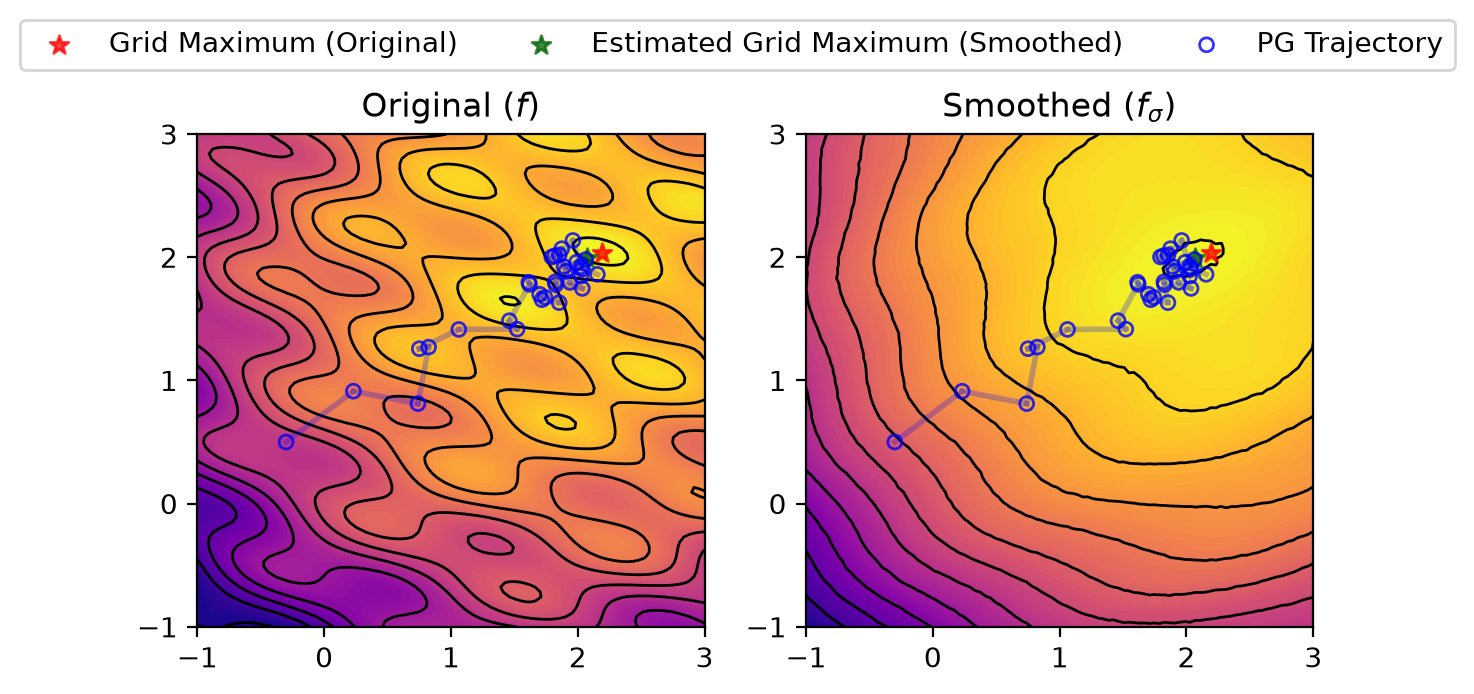

In [12]:
def pg_grad_step(x, y, N, eta, sigma):
  tx = np.random.normal(x, sigma, size=(N,)) # tilde x samples
  ty = np.random.normal(y, sigma, size=(N,)) # tilde y samples
  #############################################################################
  # TODO: Implement the policy gradient estimator for the smoothed function f #
  #############################################################################
  values = f(tx, ty)
  grad_x = np.mean((tx - x) * values) / sigma ** 2
  grad_y = np.mean((ty - y) * values) / sigma ** 2
  new_x = x + eta * grad_x
  new_y = y + eta * grad_y
  #############################################################################
  #                             END OF YOUR CODE                              #
  #############################################################################
  return new_x, new_y

num_its = 30      # number of gradient steps
eta = 0.1         # learning rate
N = 20            # number of samples for MC estimation
sigma = 0.3       # the magnitude of the Gaussian noise
x, y = -0.3, 0.5  # initial parameter values

np.random.seed(2026)  # Reset to make the default trajectory reproducible.

# history of parameter values
xs = [x]
ys = [y]

for i in range(num_its):
    x, y = pg_grad_step(x, y, N, eta, sigma)
    xs.append(x)
    ys.append(y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.2), dpi=200)
visualizer.draw(ax1, {f"PG Trajectory": {"color": "blue", "x": xs, "y": ys}}, new_opt=opt_dict[sigma], legend=False)
visualizer.draw(ax2, {f"PG Trajectory": {"color": "blue", "x": xs, "y": ys}}, new_zs=zs_dict[sigma], new_opt=opt_dict[sigma], legend=False)

ax1.set_title("Original ($f$)")
ax2.set_title(r"Smoothed ($f_\sigma$)")
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.08))
pass

Now, we are going to look at how changing $\eta$ and $N$ influences the learning trajectory. Run the following cell and drag the sliders to try it out yourself!

In [ ]:
pg_widget = get_estimator_interactive(pg_grad_step, "PG Trajectory", has_delta=False)
pg_widget


--------------
**(g) How do $\eta$ and $N$ affect policy gradient's trajectory? Compare its noise and progress with finite differences at the same $\sigma$, initial point, and update-step budget. Report the settings you compare; the same $N$ need not imply the same number of function evaluations.**

**Solution.** With $\sigma = 0.3$, start $(-0.3, 0.5)$, and 30 steps: compared with $N = 20$, $\eta = 0.1$, a larger $N$ (e.g., 100) makes the path steadier, while a smaller $\eta$ (0.01) makes it smoother but much slower. A very small $N$ can be unstable: with $N = 2$ and $\eta = 0.1$ several of our runs diverged.

Compared with finite differences at the same settings ($N = 20$, $\eta = 0.1$, $\delta = 0.25$), policy gradient reaches the high-value region in a similar number of steps (median about 7 steps versus 8 over 30 seeds), but its steps are much noisier far from the optimum. At the start, where $|f| \approx 8$, the standard deviation of the policy-gradient estimate is about 6 per coordinate versus about 1 for finite differences, because each policy-gradient sample is weighted by $f$ itself. Near the optimum, where $f$ is small, the two are similarly noisy. Note that finite differences use $3N$ function evaluations per step and policy gradient only $N$.

--------------

## Part 3c: Reparameterization Gradient

Policy gradient uses derivatives of the smoothing density. Can we use any gradient information about $f(x)$? This might seem a bit unintuitive, as the function that has lots of local optima probably have poor gradient information locally. As we will show in this part, we can average local derivatives to estimate the gradient of the smoothed function.

Let's go back to the definition of the smoothed function again (and take the gradient operator with respect to $[x, y]$):
$$\nabla f_\sigma(x, y) = \nabla \mathbb{E}_{\tilde x, \tilde y \sim \mathcal{N}([x, y], \sigma^2 I)}\left[f(\tilde x, \tilde y)\right]$$

It would be so nice if we could move the gradient inside the expectation, but that is not possible immediately because the expectation distribution depends on $x$ and $y$ and the term inside the expectation does not directly depend on $x$ and $y$. Can we somehow rewrite the expectation such that the distribution does not depend on $x$ and $y$? Or in another word, can we separate out the noise in $\tilde x$ and $\tilde y$ such that they can be rewritten as a deterministic function of $x, y$ and some noise that is independent of $x$ and $y$?

Yes! Let $z_x, z_y$ be independent samples from the Gaussian $\mathcal{N}(0, \sigma^2)$. We can simply rewrite $\tilde x$ and $\tilde y$ as follows:
$$\tilde x = z_x + x,$$
$$\tilde y = z_y + y.$$

With such a reparameterization, we can now express the smoothed function using an expectation where its distribution is independent of $x$ and $y$! For this smooth objective, we may move the gradient operator inside (Part 4 examines a case where this fails):
$$\nabla f_\sigma(x, y) = \nabla \mathbb{E}_{z_x, z_y \sim \mathcal{N}(0, \sigma^2)}\left[f(x + z_x, y + z_y)\right] = \mathbb{E}_{z_x, z_y \sim \mathcal{N}(0, \sigma^2)} \left[\nabla f(x + z_x, y + z_y)\right]$$

Writing out the derivative for $x$ and $y$ separately:
$$\frac{\partial f_\sigma(x, y)}{\partial x} = \mathbb{E}_{z_x, z_y \sim \mathcal{N}(0, \sigma^2)}\left[f_x(x + z_x, y + z_y)\right]$$
$$\frac{\partial f_\sigma(x, y)}{\partial y} = \mathbb{E}_{z_x, z_y \sim \mathcal{N}(0, \sigma^2)}\left[f_y(x + z_x, y + z_y)\right]$$
where $f_x$ is the partial derivative of $f$ with respect to the first input ($x$) and $f_y$ is the partial derivative of $f$ with respect to the second input ($y$).

As you might have already guessed it, we can perform Monte-Carlo estimate of each of the derivative by drawing $z_x$ and $z_y$ samples. The gradient estimator of such form is called the *reparameterization gradient estimator*.

Your task is to implement the `reparam_grad_step` function below. In the function, you should first estimate the gradient of the smoothed function $f_\sigma$ using the reparameterization gradient method using $\sigma$, and $N$. Then, you should use the gradient estimate to take a step with a step size of $\eta$ and return the new parameter values.

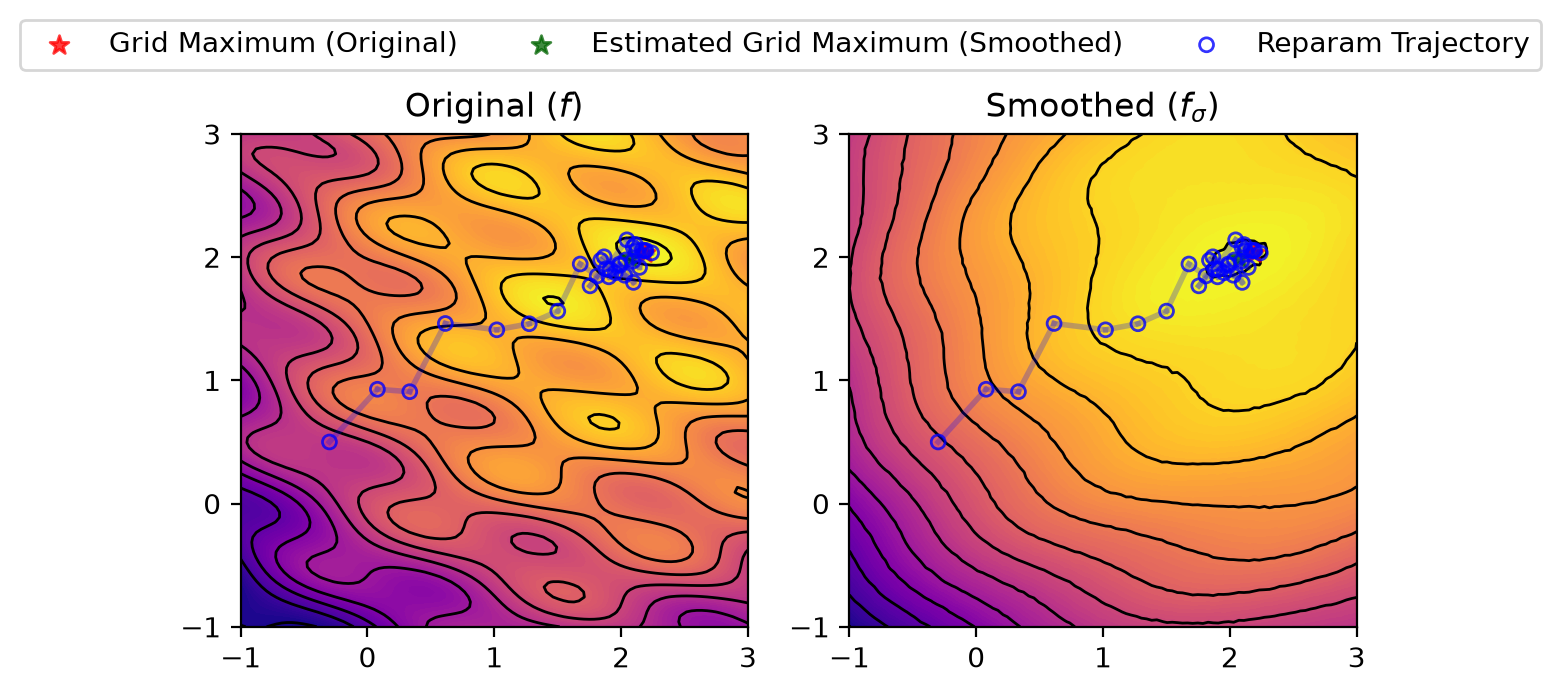

In [14]:
def reparam_grad_step(x, y, N, eta, sigma):
  tx = np.random.normal(x, sigma, size=(N,)) # tilde x samples
  ty = np.random.normal(y, sigma, size=(N,)) # tilde y samples
  #############################################################################
  # TODO: Implement the reparameterization gradient estimator of the smoothed #
  #   function f.                                                             #
  #############################################################################
  # tx = x + z_x and ty = y + z_y with z ~ N(0, sigma^2): average the gradient of f at the samples.
  dx, dy = grad_f(tx, ty)
  new_x = x + eta * np.mean(dx)
  new_y = y + eta * np.mean(dy)
  #############################################################################
  #                             END OF YOUR CODE                              #
  #############################################################################
  return new_x, new_y


num_its = 30      # number of gradient steps
eta = 0.1         # learning rate
N = 20            # number of samples for MC estimation
sigma = 0.3       # the magnitude of the Gaussian noise
x, y = -0.3, 0.5  # initial parameter values

np.random.seed(2026)  # Reset to make the default trajectory reproducible.

# history of parameter values
xs = [x]
ys = [y]

for i in range(num_its):
    x, y = reparam_grad_step(x, y, N, eta, sigma)
    xs.append(x)
    ys.append(y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.2), dpi=200)
visualizer.draw(ax1, {f"Reparam Trajectory": {"color": "blue", "x": xs, "y": ys}}, new_opt=opt_dict[sigma], legend=False)
visualizer.draw(ax2, {f"Reparam Trajectory": {"color": "blue", "x": xs, "y": ys}}, new_zs=zs_dict[sigma], new_opt=opt_dict[sigma], legend=False)

ax1.set_title("Original ($f$)")
ax2.set_title(r"Smoothed ($f_\sigma$)")
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.08))
pass

In [ ]:
reparam_widget = get_estimator_interactive(reparam_grad_step, "Reparam Trajectory", has_delta=False)
reparam_widget


--------------
**(h) Compare the smoothness and progress of the reparameterization-gradient and policy-gradient trajectories at the same settings. Explain any difference using the information each estimator uses. A stochastic trajectory can vary across runs.**

**Solution.** At the same settings ($N = 20$, $\eta = 0.1$, $\sigma = 0.3$) the reparameterization trajectory is clearly smoother early on and makes slightly faster progress (median about 6 steps to the high-value region, versus about 7 for policy gradient). Far from the optimum its gradient estimate has a standard deviation of about 1 per coordinate, versus about 6 for policy gradient. The reason is the information each estimator uses: reparameterization averages the actual derivative $\nabla f$ at the sampled points, which already points uphill, while policy gradient only uses the function values and must infer the direction from how they vary across samples, so its noise grows with $|f|$. Near the optimum the two estimators have similar noise. Individual stochastic runs can differ.

--------------

## Part 4: Objective functions with discontinuities

In the previous part, we introduced three techniques to estimate the gradient of a smoothed function. In this part, we are going to explore a more extreme objective function that contains discontinuities, $f_q(x, y)$. $f_q$ is obtained by quantizing the previous objective: $f_q(x,y)=\lfloor f(x,y)/4.5+0.64\rfloor$. Can we use what we have learned so far to optimize this objective function?

Let's first visualize what the function looks like!

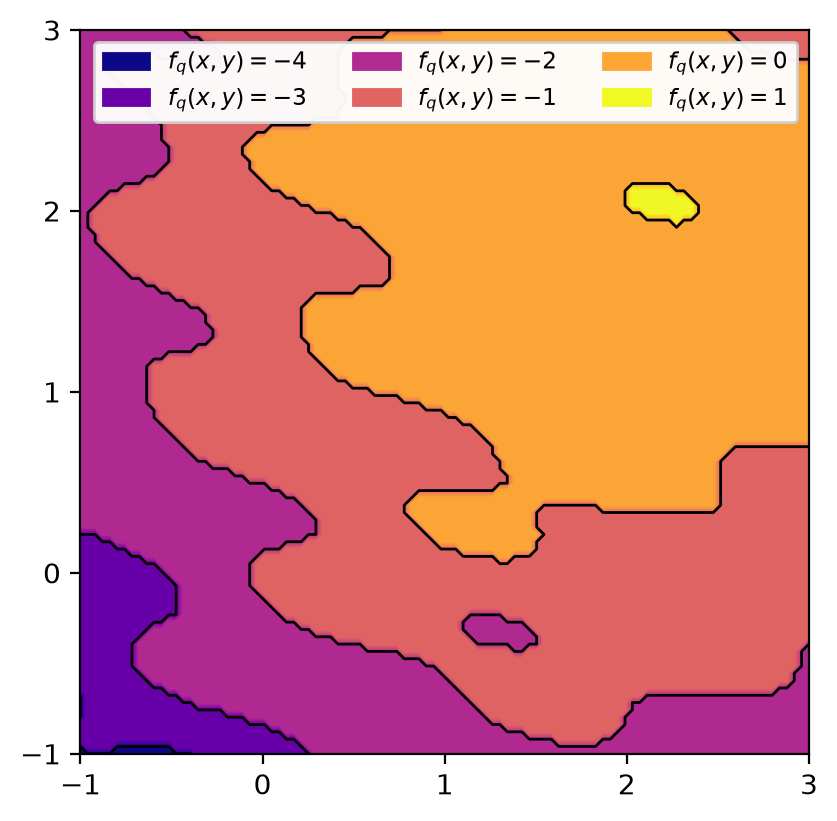

In [16]:
def quantize(s):
  return np.floor(s / 4.5 + 0.64)

def qf(x, y):
  return quantize(f(x, y))

q_visualizer = Visualizer(qf, n_contour_lines=5, quantized_values=[-4, -3, -2, -1, 0, 1])

fig, ax = plt.subplots(1, 1, figsize=(4.70, 4.70), dpi=200)
q_visualizer.draw(ax, legend=False)

On the plotted region, the function outputs values from $\{-4, -3, -2, -1, 0, 1\}$ with $f_q(x, y) = 1$ being the maximum value (located top right, yellow region).

--------------
**(i) How well do you expect ordinary gradient ascent applied directly to the quantized function $f_q$ to perform? Explain what its gradient is inside a constant region and at a jump boundary.**

**Solution.** Ordinary gradient ascent fails. Inside each constant region $f_q$ is flat, so its gradient is exactly zero and the parameters never move. At a jump boundary the derivative does not exist (it would be infinite), and a step lands on that boundary with probability zero, so it never helps.

**(j) If you apply the ordinary reparameterization estimator from Part 3c directly to $f_q$, does it give a useful estimate of the gradient of its Gaussian-smoothed objective? Explain why. Consider the estimator as written, without replacing the derivative by a surrogate.**

**Solution.** No. The reparameterization estimator averages $\nabla f_q$ at the sampled points, and the samples land on a jump boundary with probability zero, so every term is zero and the estimate is exactly $0$. Yet the Gaussian-smoothed objective $\mathbb{E}[f_q(x + z_x, y + z_y)]$ is smooth and has a nonzero gradient: it comes entirely from the jumps, which act like delta functions in the derivative. The step of moving the gradient inside the expectation is not valid for this discontinuous function, so the estimator misses all of that signal. Policy gradient avoids the problem because it only uses function values.

--------------

Implement the policy-gradient update for the quantized objective below, using `qf` in place of `f`. Try to reach a region with $f_q=1$ in 30 update steps with $N\leq50$. Repeat with several random seeds and report the settings and observed success; an individual stochastic run need not succeed. The unused `delta` argument is retained if you want to explore finite differences as well.


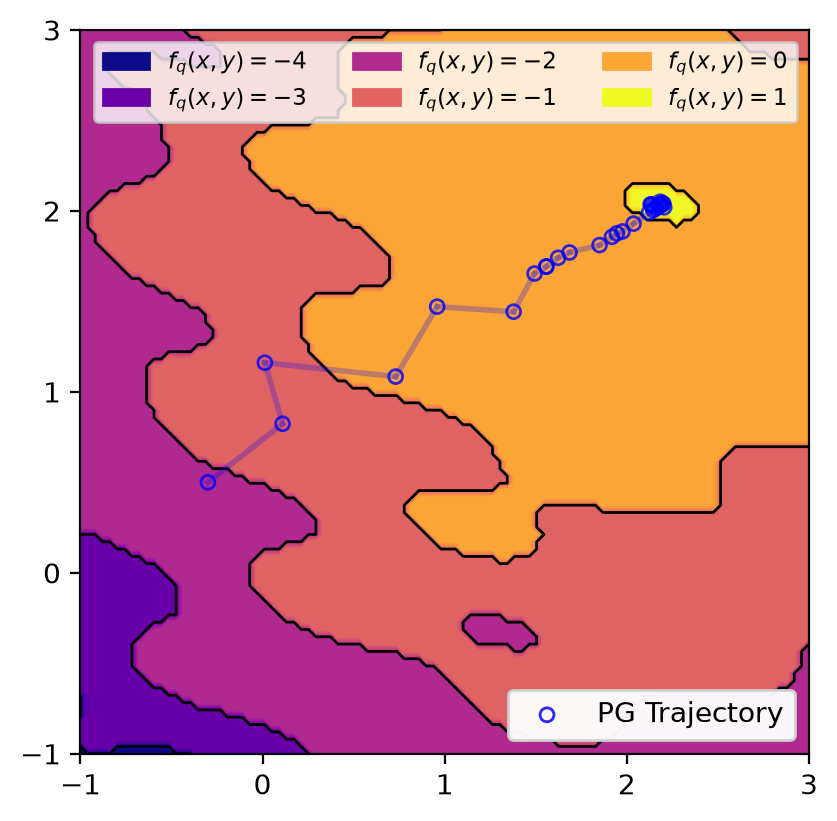

In [17]:
def q_grad_step(x, y, N, eta, sigma, delta):
  tx = np.random.normal(x, sigma, size=(N,)) # tilde x samples
  ty = np.random.normal(y, sigma, size=(N,)) # tilde y samples
  #############################################################################
  # TODO: Implement the policy gradient  estimate of the gradient of the      #
  # smoothed function f. (Hint: make sure to use qf instead of f as used      #
  # previously                                                                #
  #############################################################################
  values = qf(tx, ty)
  grad_x = np.mean((tx - x) * values) / sigma ** 2
  grad_y = np.mean((ty - y) * values) / sigma ** 2
  new_x = x + eta * grad_x
  new_y = y + eta * grad_y
  #############################################################################
  #                             END OF YOUR CODE                              #
  #############################################################################
  return new_x, new_y

num_its = 30      # number of gradient steps
eta = 0.5         # learning rate
N = 50            # number of samples for MC estimation
sigma = 0.3       # the magnitude of the Gaussian noise
delta = 0.25      # finite difference magnitude
x, y = -0.3, 0.5  # initial parameter values

np.random.seed(2026)  # Reset to make the default trajectory reproducible.

# history of parameter values
xs = [x]
ys = [y]

#############################################################################
# TODO: Implement the for loop that takes policy gradient steps. Make sure  #
# to append your intermediate x and y values into the list xs and ys so that#
# the training trajectory can be visualized later (hint: you might find the #
# code you have seen in the previous part helpful)                          #
#############################################################################
for i in range(num_its):
    x, y = q_grad_step(x, y, N, eta, sigma, delta)
    xs.append(x)
    ys.append(y)
#############################################################################
#                             END OF YOUR CODE                              #
#############################################################################

fig, ax = plt.subplots(1, 1, figsize=(4.70, 4.70), dpi=200)
q_visualizer.draw(ax, {f"PG Trajectory": {"color": "blue", "x": xs, "y": ys}})

In [18]:
# Repeat the quantized-objective experiment over many seeds and report how often
# the final iterate reaches the region where f_q = 1.
def quantized_success(eta, N, sigma=0.3, num_its=30, seeds=range(100)):
    successes = 0
    for seed in seeds:
        np.random.seed(seed)
        x, y = -0.3, 0.5
        for _ in range(num_its):
            x, y = q_grad_step(x, y, N, eta, sigma, delta)
        successes += int(qf(x, y) == 1)
    return successes / len(seeds)

for eta_q, N_q in [(0.3, 50), (0.5, 20), (0.5, 50), (1.0, 50)]:
    print(f"eta={eta_q}, N={N_q}, sigma=0.3, 30 steps: reached f_q = 1 in {quantized_success(eta_q, N_q):.0%} of 100 seeds")


eta=0.3, N=50, sigma=0.3, 30 steps: reached f_q = 1 in 5% of 100 seeds
eta=0.5, N=20, sigma=0.3, 30 steps: reached f_q = 1 in 73% of 100 seeds
eta=0.5, N=50, sigma=0.3, 30 steps: reached f_q = 1 in 80% of 100 seeds
eta=1.0, N=50, sigma=0.3, 30 steps: reached f_q = 1 in 99% of 100 seeds


**Solution.** Policy gradient works on $f_q$ because it only needs function values: samples that land in a higher level push $(x, y)$ toward them, so the smoothed objective's gradient is estimated even though $f_q$ itself is flat almost everywhere. With the supplied settings ($\eta = 0.5$, $N = 50$, $\sigma = 0.3$, 30 steps) the default seed reaches the yellow $f_q = 1$ region, and the seed sweep above shows how often this happens across 100 seeds. A larger step size reaches the top region more reliably within 30 steps, a smaller one often runs out of steps, and fewer samples make the steps noisier.